# 02 - Chignolin CV Transformer
Use a tensor history encoder for the peptide trajectories, then select the best CV on validation mutants and evaluate that exact checkpoint on test mutants.

In [14]:
import sys
import random
from copy import deepcopy
from pathlib import Path

SRC_DIR = (Path.cwd().resolve() / '..' / 'src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from course_project.models.cv_core import CVCoreConfig, CVCoreInput, SharedCVCore


In [15]:
seed = int(torch.seed() % (2**32 - 1))
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
rng = np.random.default_rng(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('run seed:', seed)

# Data 
peptide_dir = Path('../data/peptide')
packed_path = peptide_dir / 'hlda_trajectories_compact.pt'
tm_csv = peptide_dir / 'Tm.csv'
mfpt_csv = peptide_dir / 'mfpt_slice_thr0p34_tF0p25_tU0p57.csv'
evalue_csv = peptide_dir / 'hlda_evalues_thr0p34_tF0p25_tU0p57.csv'

# Split parameters
train_mutant_count = 5
val_mutant_count = 15
exclude_mutants = {'Y0R'}

# Data / window parameters
history = 4
use_distance_only = True
stride_train = 5
stride_eval = 20
max_steps_train_per_traj = 50000
max_steps_eval_per_traj = 50000
max_windows_train_per_traj = None
max_windows_eval_per_traj = 200

# Model / training parameters
hidden_size = 160
K1 = 250
CV = 6
heads = 1
transformer_layers = 1
dropout = 0.001
batch_size = 256
learning_rate = 8e-5
weight_decay = 0.0
cls_weight = 0.5
epochs = 20
eval_every = 1

# Validation score weights
w_spearman = 0.7
w_pearson = 0.3


def load_target_table():
    tm_df = pd.read_csv(tm_csv)
    mfpt_df = pd.read_csv(mfpt_csv)
    evalue_df = pd.read_csv(evalue_csv)

    tm_df['Mutant'] = tm_df['Mutant'].astype(str).str.strip()
    mfpt_df['Mutant'] = mfpt_df['Mutant'].astype(str).str.strip()
    evalue_df['Mutant'] = evalue_df['Mutant'].astype(str).str.strip()

    tm_df['Tm'] = pd.to_numeric(tm_df['Tm'].astype(str).str.strip(), errors='coerce')
    mfpt_df['mfpt'] = pd.to_numeric(mfpt_df['mfpt'], errors='coerce')
    evalue_df['hlda_evalue'] = pd.to_numeric(evalue_df['hlda_evalue'], errors='coerce')

    tm_wt = float(tm_df.loc[tm_df['Mutant'].str.upper() == 'WT', 'Tm'].dropna().iloc[0])
    mfpt_wt = float(mfpt_df.loc[mfpt_df['Mutant'].str.upper() == 'WT', 'mfpt'].dropna().iloc[0])

    out = (
        tm_df[['Mutant', 'Tm']]
        .merge(mfpt_df[['Mutant', 'mfpt']], on='Mutant', how='inner')
        .merge(evalue_df[['Mutant', 'hlda_evalue']], on='Mutant', how='inner')
    )
    out['mutant'] = out['Mutant']
    out['mfpt_ratio'] = out['mfpt'] / mfpt_wt
    out['log_mfpt_ratio'] = np.log(out['mfpt_ratio'])
    return out[['mutant', 'Tm', 'mfpt', 'mfpt_ratio', 'log_mfpt_ratio', 'hlda_evalue']]


target_df = load_target_table()
target_mutants = set(target_df['mutant'].astype(str).tolist())

packed = torch.load(packed_path, weights_only=False)
x_raw = packed['x'].float()
time_all = packed['time'].float()
offsets = packed['traj_offsets'].long()
labels = packed['labels'].long()
mutants = list(packed['mutants'])
feature_names_all = list(packed['feature_names'])

distance_idx = [i for i, n in enumerate(feature_names_all) if str(n).startswith('d')]
feature_idx = distance_idx if use_distance_only else list(range(len(feature_names_all)))
x_all = x_raw[:, feature_idx]
feature_names = [feature_names_all[i] for i in feature_idx]
n_feat = int(x_all.shape[1])


def traj_slice(traj_id: int):
    s = int(offsets[traj_id])
    e = int(offsets[traj_id + 1])
    return x_all[s:e], time_all[s:e]


uniq_mutants = sorted({
    m for m in set(mutants)
    if str(m).strip().upper() not in exclude_mutants and str(m) in target_mutants
})
rng.shuffle(uniq_mutants)

train_mutants = list(uniq_mutants[:train_mutant_count])
val_mutants = list(uniq_mutants[train_mutant_count:train_mutant_count + val_mutant_count])
test_mutants = list(uniq_mutants[train_mutant_count + val_mutant_count:])


def ids_for_mutants(mutant_names):
    wanted = set(mutant_names)
    return [i for i, m in enumerate(mutants) if m in wanted]


train_ids = ids_for_mutants(train_mutants)
val_ids = ids_for_mutants(val_mutants)
test_ids = ids_for_mutants(test_mutants)

print('packed path:', packed_path)
print('feature count:', n_feat)
print('train mutants:', len(train_mutants), 'val mutants:', len(val_mutants), 'test mutants:', len(test_mutants))
print('train trajs:', len(train_ids), 'val trajs:', len(val_ids), 'test trajs:', len(test_ids))
print('train mutants list:', train_mutants)
print('val mutants list:', val_mutants)
print('test mutants list:', test_mutants[:10], '...')


device: cuda
run seed: 2064335528
packed path: ../data/peptide/hlda_trajectories_compact.pt
feature count: 28
train mutants: 5 val mutants: 15 test mutants: 16
train trajs: 10 val trajs: 30 test trajs: 32
train mutants list: ['T7R', 'D2E', 'Y9G', 'Y9R', 'Y9Q']
val mutants list: ['T7Y', 'D2R', 'T5R', 'T7D', 'P3C', 'D2C', 'Y9E', 'P3R', 'Y9A', 'D2Y', 'D2K', 'Y9V', 'Y0A', 'P3D', 'T5Y']
test mutants list: ['WT', 'T5G', 'D2A', 'Y9K', 'E4R', 'D2N', 'E4A', 'Y0E', 'E4Y', 'T7V'] ...


In [16]:
def make_window_index(traj_ids, history, stride, max_per_traj=None, max_steps_per_traj=None):
    index = []
    for tid in traj_ids:
        xt, _ = traj_slice(tid)
        if max_steps_per_traj is not None:
            xt = xt[:max_steps_per_traj]
        t_start = history - 1
        t_end = xt.shape[0] - 1
        if t_end <= t_start:
            continue
        ts = list(range(t_start, t_end, stride))
        if max_per_traj is not None and len(ts) > max_per_traj:
            pick = np.linspace(0, len(ts) - 1, max_per_traj, dtype=int)
            ts = [ts[j] for j in pick]
        index.extend((tid, t) for t in ts)
    return index


train_index = make_window_index(train_ids, history, stride_train, max_windows_train_per_traj, max_steps_train_per_traj)
val_index = make_window_index(val_ids, history, stride_eval, max_windows_eval_per_traj, max_steps_eval_per_traj)
test_index = make_window_index(test_ids, history, stride_eval, max_windows_eval_per_traj, max_steps_eval_per_traj)

print('windows:', len(train_index), len(val_index), len(test_index))


def compute_norm_stats(traj_ids, history, stride=20, max_steps_per_traj=None):
    x_sum = torch.zeros(n_feat)
    x_sq = torch.zeros(n_feat)
    x_cnt = 0
    dv_sum = torch.zeros(n_feat)
    dv_sq = torch.zeros(n_feat)
    dv_cnt = 0

    for tid in traj_ids:
        xt, _ = traj_slice(tid)
        if max_steps_per_traj is not None:
            xt = xt[:max_steps_per_traj]
        x_sum += xt.sum(dim=0)
        x_sq += (xt * xt).sum(dim=0)
        x_cnt += xt.shape[0]
        for t in range(history - 1, xt.shape[0] - 1, stride):
            cur_v = xt[t] - xt[t - 1]
            nxt_v = xt[t + 1] - xt[t]
            dv = nxt_v - cur_v
            dv_sum += dv
            dv_sq += dv * dv
            dv_cnt += 1

    x_mean = x_sum / x_cnt
    x_var = x_sq / x_cnt - x_mean * x_mean
    x_std = torch.sqrt(torch.clamp(x_var, min=1e-8))

    dv_mean = dv_sum / dv_cnt
    dv_var = dv_sq / dv_cnt - dv_mean * dv_mean
    dv_std = torch.sqrt(torch.clamp(dv_var, min=1e-8))
    return x_mean, x_std, dv_mean, dv_std


x_mean, x_std, dv_mean, dv_std = compute_norm_stats(
    train_ids,
    history,
    stride=stride_train,
    max_steps_per_traj=max_steps_train_per_traj,
)
print('norm stats ready')


class HLDADVDataset(Dataset):
    def __init__(self, index):
        self.index = index

    def __len__(self):
        return len(self.index)

    def __getitem__(self, i):
        tid, t = self.index[i]
        xt, _ = traj_slice(tid)
        hist = xt[t - history + 1 : t + 1]
        cur_v = xt[t] - xt[t - 1]
        nxt_v = xt[t + 1] - xt[t]
        dv = nxt_v - cur_v
        hist_n = (hist - x_mean) / x_std
        dv_n = (dv - dv_mean) / dv_std
        y_cls = labels[tid].float()
        return hist_n, dv_n, y_cls


train_ds = HLDADVDataset(train_index)
val_ds = HLDADVDataset(val_index)
test_ds = HLDADVDataset(test_index)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)

print('batches:', len(train_loader), len(val_loader), len(test_loader))


windows: 100000 6000 6400
norm stats ready
batches: 391 24 25


In [17]:
class SequenceHistoryAdapter(nn.Module):
    # Adapter contract: take raw sequence history and return CVCoreInput(tokens, mask, local_skip).
    def __init__(self, feat_dim, history, hidden_size):
        super().__init__()
        self.in_proj = nn.Linear(feat_dim, hidden_size)
        self.pos_emb = nn.Parameter(torch.randn(history, hidden_size) * 0.01)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.in_proj.weight)
        if self.in_proj.bias is not None:
            nn.init.zeros_(self.in_proj.bias)
        nn.init.normal_(self.pos_emb, mean=0.0, std=0.01)

    def build_core_input(self, x_hist) -> CVCoreInput:
        tokens = self.in_proj(x_hist) + self.pos_emb.unsqueeze(0)
        return CVCoreInput(tokens=tokens)


class ChignolinCVModel(nn.Module):
    def __init__(self, feat_dim, history, hidden, k1_tokens, k_cv, heads, token_layers, dropout):
        super().__init__()
        self.adapter = SequenceHistoryAdapter(feat_dim, history, hidden)
        self.core = SharedCVCore(
            CVCoreConfig(
                hidden_size=hidden,
                K1=k1_tokens,
                cv_count=k_cv,
                output_dim=feat_dim,
                transformer_layers=token_layers,
                transformer_heads=heads,
                transformer_dropout=dropout,
                decode_mode='global',
                use_local_skip=False,
            )
        )
        self.cls_head = nn.Sequential(
            nn.Linear(k_cv, hidden // 2),
            nn.GELU(),
            nn.Linear(hidden // 2, 1),
        )
        self.reset_parameters()

    def reset_parameters(self):
        for module in self.cls_head.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x_hist):
        core_input = self.adapter.build_core_input(x_hist)
        output = self.core(core_input)
        cv = output.cv
        cls_logit = self.cls_head(cv).squeeze(-1)
        return output.prediction, cls_logit, cv


model = ChignolinCVModel(
    feat_dim=n_feat,
    history=history,
    hidden=hidden_size,
    k1_tokens=K1,
    k_cv=CV,
    heads=heads,
    token_layers=transformer_layers,
    dropout=dropout,
).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
print(model.__class__.__name__)
print('shared core token sizes:', model.core.token_sizes)


ChignolinCVModel
shared core token sizes: [250, 72, 21, 6]


In [18]:
def run_epoch(loader, train_mode=True):
    model.train(train_mode)
    loss_sum = 0.0
    dv_loss_sum = 0.0
    cls_loss_sum = 0.0
    n = 0
    y_true = []
    y_prob = []

    for xh, y_dv, y_cls in loader:
        xh = xh.to(device)
        y_dv = y_dv.to(device)
        y_cls = y_cls.to(device)

        with torch.set_grad_enabled(train_mode):
            dv_pred, cls_logit, _ = model(xh)
            loss_dv = F.mse_loss(dv_pred, y_dv)
            if cls_weight > 0:
                loss_cls = F.binary_cross_entropy_with_logits(cls_logit, y_cls)
                loss = loss_dv + cls_weight * loss_cls
            else:
                loss_cls = torch.zeros((), device=loss_dv.device)
                loss = loss_dv
            if train_mode:
                opt.zero_grad()
                loss.backward()
                opt.step()

        b = xh.size(0)
        n += b
        loss_sum += loss.item() * b
        dv_loss_sum += loss_dv.item() * b
        cls_loss_sum += loss_cls.item() * b
        y_true.append(y_cls.detach().cpu())
        y_prob.append(torch.sigmoid(cls_logit).detach().cpu())

    y_true = torch.cat(y_true).numpy()
    y_prob = torch.cat(y_prob).numpy()
    y_pred = (y_prob >= 0.5).astype(np.int64)

    out = {
        'loss': loss_sum / n,
        'dv_mse': dv_loss_sum / n,
        'cls_bce': cls_loss_sum / n,
        'cls_acc': float((y_pred == y_true).mean()) if cls_weight > 0 else float('nan'),
    }
    return out


@torch.no_grad()
def cv_rows_for_traj(xt, max_windows_per_traj):
    model.eval()
    if max_steps_eval_per_traj is not None:
        xt = xt[:max_steps_eval_per_traj]
    t_start = history - 1
    t_end = xt.shape[0] - 1
    if t_end <= t_start:
        return []
    ts = list(range(t_start, t_end, stride_eval))
    if max_windows_per_traj is not None and len(ts) > max_windows_per_traj:
        pick = np.linspace(0, len(ts) - 1, max_windows_per_traj, dtype=int)
        ts = [ts[j] for j in pick]
    rows = []
    for t in ts:
        hist = xt[t - history + 1 : t + 1]
        hist_n = ((hist - x_mean) / x_std).unsqueeze(0).to(device)
        _, _, cv = model(hist_n)
        rows.append(cv[0].detach().cpu().numpy())
    return rows


@torch.no_grad()
def epoch_mean_cv_df(mutant_names, pool_ids):
    model.eval()
    rows = []
    for mname in mutant_names:
        traj_ids_m = [i for i in pool_ids if mutants[i] == mname]
        cv_rows = []
        for tid in traj_ids_m:
            xt, _ = traj_slice(tid)
            cv_rows.extend(cv_rows_for_traj(xt, max_windows_eval_per_traj))
        if len(cv_rows) == 0:
            continue
        arr = np.asarray(cv_rows)
        vec = np.mean(arr, axis=0)
        row = {'mutant': mname}
        for i, v in enumerate(vec, start=1):
            row[f'CV{i}'] = float(v)
        rows.append(row)
    return pd.DataFrame(rows)


def merged_cv_target_for_pool(mutant_names, pool_ids):
    cv_df = epoch_mean_cv_df(mutant_names, pool_ids)
    if cv_df.empty:
        return pd.DataFrame()
    return cv_df.merge(target_df, on='mutant', how='inner')


def best_metric_from_merged(merged, metric):
    if merged.empty:
        return {'score': float('nan'), 'cv': None, 'n': 0, 'spearman': float('nan'), 'pearson': float('nan')}
    cv_cols = [c for c in merged.columns if c.startswith('CV')]
    best = {'score': float('-inf'), 'cv': None, 'n': 0, 'spearman': float('nan'), 'pearson': float('nan')}
    for cv in cv_cols:
        sub = merged[[cv, metric]].dropna()
        n = int(len(sub))
        if n < 3:
            continue
        s = float(sub[cv].corr(sub[metric], method='spearman'))
        p = float(sub[cv].corr(sub[metric], method='pearson'))
        if not np.isfinite(s) or not np.isfinite(p):
            continue
        score = w_spearman * abs(s) + w_pearson * abs(p)
        if score > best['score']:
            best = {'score': float(score), 'cv': cv, 'n': n, 'spearman': float(s), 'pearson': float(p)}
    if best['cv'] is None:
        return {'score': float('nan'), 'cv': None, 'n': 0, 'spearman': float('nan'), 'pearson': float('nan')}
    return best


history_rows = []
val_metric_rows = []
checkpoints = []
best_by_metric = {
    metric: {
        'score': float('-inf'),
        'epoch': None,
        'cv': None,
        'spearman': float('nan'),
        'pearson': float('nan'),
        'state': None,
    }
    for metric in ['Tm', 'log_mfpt_ratio', 'hlda_evalue']
}

run_dir = Path('../results') / 'chignolin_cv_transformer'
run_dir.mkdir(parents=True, exist_ok=True)
ckpt_dir = run_dir / 'checkpoints'
ckpt_dir.mkdir(parents=True, exist_ok=True)

for epoch in range(1, epochs + 1):
    tr = run_epoch(train_loader, train_mode=True)
    va = run_epoch(val_loader, train_mode=False)
    te = run_epoch(test_loader, train_mode=False)

    row = {
        'epoch': epoch,
        'train_loss': tr['loss'],
        'val_loss': va['loss'],
        'test_loss': te['loss'],
        'train_dv_mse': tr['dv_mse'],
        'val_dv_mse': va['dv_mse'],
        'test_dv_mse': te['dv_mse'],
    }

    if epoch % eval_every == 0:
        merged_val = merged_cv_target_for_pool(val_mutants, val_ids)
        best_text = 'none'
        best_score = float('nan')
        for metric in ['Tm', 'log_mfpt_ratio', 'hlda_evalue']:
            best = best_metric_from_merged(merged_val, metric)
            val_metric_rows.append({
                'epoch': epoch,
                'metric': metric,
                'val_best_score': float(best['score']),
                'val_best_cv': best['cv'],
                'val_best_spearman': float(best['spearman']),
                'val_best_pearson': float(best['pearson']),
                'val_n': int(best['n']),
            })
            if np.isfinite(best['score']) and best['score'] > best_by_metric[metric]['score']:
                best_by_metric[metric] = {
                    'score': float(best['score']),
                    'epoch': epoch,
                    'cv': best['cv'],
                    'spearman': float(best['spearman']),
                    'pearson': float(best['pearson']),
                    'state': deepcopy(model.state_dict()),
                }
            if np.isfinite(best['score']) and (not np.isfinite(best_score) or best['score'] > best_score):
                best_score = float(best['score'])
                best_text = f"{metric}/{best['cv']} score={best['score']:.3g} |S|={abs(best['spearman']):.3g} |P|={abs(best['pearson']):.3g}"

        ckpt_path = ckpt_dir / f'epoch_{epoch:04d}.pt'
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict()}, ckpt_path)
        checkpoints.append({'epoch': epoch, 'path': str(ckpt_path)})
        print(f"[ep {epoch:>3}/{epochs}] tr={tr['loss']:.3g} va={va['loss']:.3g} best_cv={best_text}")
    else:
        print(f"[ep {epoch:>3}/{epochs}] tr={tr['loss']:.3g} va={va['loss']:.3g}")

    history_rows.append(row)

history_df = pd.DataFrame(history_rows)
val_metric_history_df = pd.DataFrame(val_metric_rows)
selection_rows = []
selected_test_payload = {}

for metric in ['Tm', 'log_mfpt_ratio', 'hlda_evalue']:
    best = best_by_metric[metric]
    if best['state'] is None:
        continue
    model.load_state_dict(best['state'])
    val_merged = merged_cv_target_for_pool(val_mutants, val_ids)
    test_merged = merged_cv_target_for_pool(test_mutants, test_ids)
    cv_col = best['cv']
    val_sub = val_merged[[cv_col, metric, 'mutant']].dropna()
    test_sub = test_merged[[cv_col, metric, 'mutant']].dropna()
    val_s = float(val_sub[cv_col].corr(val_sub[metric], method='spearman'))
    val_p = float(val_sub[cv_col].corr(val_sub[metric], method='pearson'))
    test_s = float(test_sub[cv_col].corr(test_sub[metric], method='spearman'))
    test_p = float(test_sub[cv_col].corr(test_sub[metric], method='pearson'))
    selection_rows.append({
        'metric': metric,
        'best_epoch': int(best['epoch']),
        'best_cv': cv_col,
        'val_score': float(best['score']),
        'val_spearman': val_s,
        'val_pearson': val_p,
        'test_spearman': test_s,
        'test_pearson': test_p,
        'test_n': int(len(test_sub)),
    })
    selected_test_payload[metric] = {
        'best_epoch': int(best['epoch']),
        'cv': cv_col,
        'val_merged': val_merged,
        'test_merged': test_merged,
        'val_spearman': val_s,
        'val_pearson': val_p,
        'test_spearman': test_s,
        'test_pearson': test_p,
    }

selection_summary_df = pd.DataFrame(selection_rows)
history_df.to_csv(run_dir / 'history.csv', index=False)
val_metric_history_df.to_csv(run_dir / 'val_metric_history.csv', index=False)
selection_summary_df.to_csv(run_dir / 'selection_summary.csv', index=False)
print(selection_summary_df)


[ep   1/20] tr=1.1 va=1.02 best_cv=hlda_evalue/CV1 score=0.622 |S|=0.625 |P|=0.617
[ep   2/20] tr=1 va=1.02 best_cv=log_mfpt_ratio/CV1 score=0.23 |S|=0.25 |P|=0.183
[ep   3/20] tr=1 va=1.02 best_cv=Tm/CV1 score=0.72 |S|=0.724 |P|=0.711
[ep   4/20] tr=0.976 va=0.915 best_cv=log_mfpt_ratio/CV1 score=0.258 |S|=0.236 |P|=0.311
[ep   5/20] tr=0.857 va=0.858 best_cv=hlda_evalue/CV1 score=0.313 |S|=0.254 |P|=0.451
[ep   6/20] tr=0.82 va=0.832 best_cv=Tm/CV1 score=0.398 |S|=0.452 |P|=0.271
[ep   7/20] tr=0.811 va=0.829 best_cv=hlda_evalue/CV1 score=0.338 |S|=0.318 |P|=0.385
[ep   8/20] tr=0.806 va=0.826 best_cv=Tm/CV1 score=0.187 |S|=0.204 |P|=0.148
[ep   9/20] tr=0.803 va=0.822 best_cv=hlda_evalue/CV1 score=0.448 |S|=0.454 |P|=0.435
[ep  10/20] tr=0.802 va=0.823 best_cv=Tm/CV1 score=0.345 |S|=0.382 |P|=0.258
[ep  11/20] tr=0.801 va=0.823 best_cv=hlda_evalue/CV1 score=0.34 |S|=0.346 |P|=0.324
[ep  12/20] tr=0.8 va=0.822 best_cv=hlda_evalue/CV1 score=0.305 |S|=0.264 |P|=0.402
[ep  13/20] tr=0.7

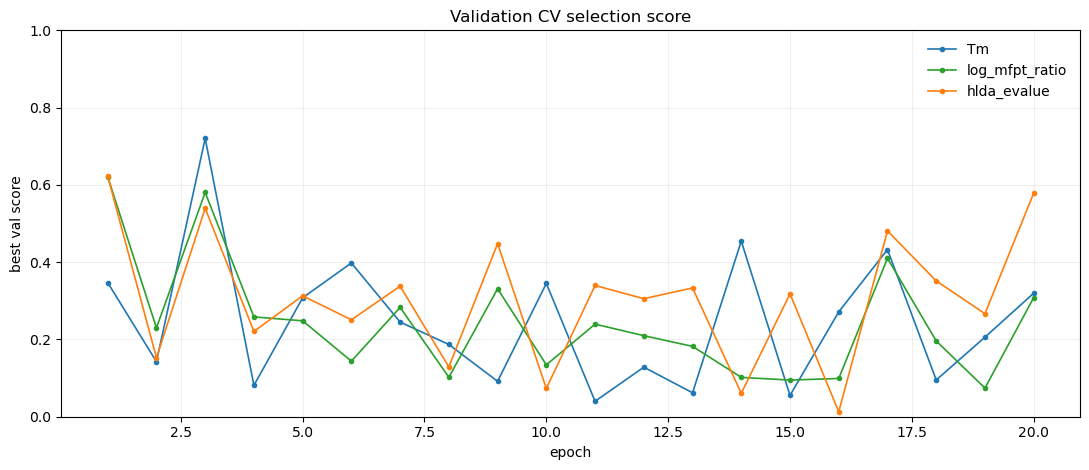

In [19]:
fig, ax = plt.subplots(figsize=(11, 4.8))
for metric, color in [('Tm', 'tab:blue'), ('log_mfpt_ratio', 'tab:green'), ('hlda_evalue', 'tab:orange')]:
    sub = val_metric_history_df[val_metric_history_df['metric'] == metric]
    ax.plot(sub['epoch'], sub['val_best_score'], marker='o', ms=3, lw=1.2, color=color, label=metric)
ax.set_xlabel('epoch')
ax.set_ylabel('best val score')
ax.set_title('Validation CV selection score')
ax.set_ylim(0, 1)
ax.grid(alpha=0.2)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


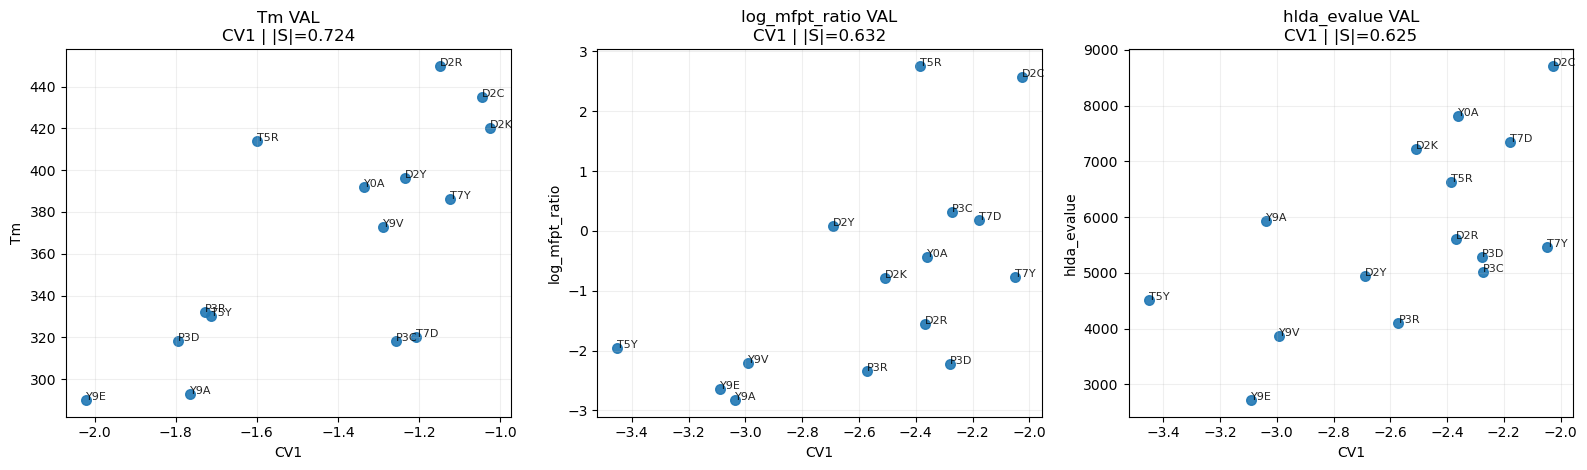

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, metric in zip(np.asarray(axes).reshape(-1), ['Tm', 'log_mfpt_ratio', 'hlda_evalue']):
    payload = selected_test_payload.get(metric)
    if payload is None:
        ax.set_axis_off()
        continue
    cv = payload['cv']
    sub = payload['val_merged'][[cv, metric, 'mutant']].dropna()
    ax.scatter(sub[cv], sub[metric], s=48, alpha=0.9)
    for _, r in sub.iterrows():
        ax.text(r[cv], r[metric], str(r['mutant']), fontsize=8, alpha=0.85)
    ax.set_title(f"{metric} VAL\n{cv} | |S|={abs(payload['val_spearman']):.3f}")
    ax.set_xlabel(cv)
    ax.set_ylabel(metric)
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


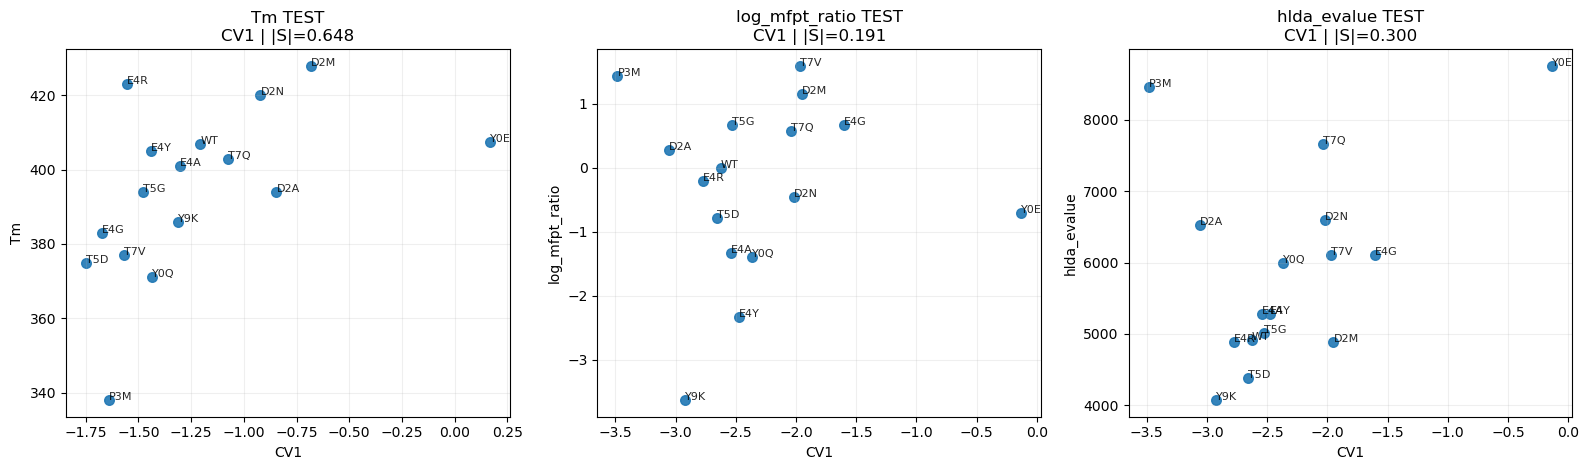

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, metric in zip(np.asarray(axes).reshape(-1), ['Tm', 'log_mfpt_ratio', 'hlda_evalue']):
    payload = selected_test_payload.get(metric)
    if payload is None:
        ax.set_axis_off()
        continue
    cv = payload['cv']
    sub = payload['test_merged'][[cv, metric, 'mutant']].dropna()
    ax.scatter(sub[cv], sub[metric], s=48, alpha=0.9)
    for _, r in sub.iterrows():
        ax.text(r[cv], r[metric], str(r['mutant']), fontsize=8, alpha=0.85)
    ax.set_title(f"{metric} TEST\n{cv} | |S|={abs(payload['test_spearman']):.3f}")
    ax.set_xlabel(cv)
    ax.set_ylabel(metric)
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
